### Section 1: Project Note

This notebook generates and inspects a simulated imaging-derived feature dataset.

The Goal is not to reproduce a clinical study or make real patient predictions. Instead, this dataset is used to demonstrate research workflow skills such as subject-level feature construction, feature group organization, model-ready data preperation and exploratory analysis.

The simulated features are inspired by neuroimaging ML workflows that use lesion-style regional features, ALFF-style signal features, and functional connectivity-style features. 

### Section 2: Import libraries

In [3]:
import sys
import os

sys.path.append(os.path.abspath('..'))

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.simulate_features import generate_simulated_pte_features

### Section 3: Generate Data

In [7]:
df = generate_simulated_pte_features(
    n_subjects=300,
    random_state=42,
    output_path="data/simulated_pte_features.csv"
)

df.head()

,subject_id,right_temporal_lesion_volume,left_temporal_lesion_volume,right_occipital_lesion_volume,left_occipital_lesion_volume,cerebellum_lesion_volume,right_parietal_lesion_volume,right_temporal_alff,left_temporal_alff,right_occipital_alff,left_occipital_alff,right_parietal_alff,temporal_occipital_connectivity,temporal_cerebellum_connectivity,frontal_temporal_connectivity,parietal_occipital_connectivity,label
0,SUBJ_204,2.325100,1.642120,1.064650,1.332123,1.631803,1.086499,0.707887,0.547716,0.554608,0.455691,0.534352,0.468461,0.466343,0.089005,0.421831,1
1,SUBJ_267,1.932099,2.042947,1.981678,1.616930,1.641002,1.322292,0.492168,0.624073,0.570617,0.821878,0.548757,0.342300,0.324315,0.084700,0.482010,1
2,SUBJ_153,1.474412,1.726660,2.441934,2.305522,1.058055,1.234558,0.289301,0.561662,0.538511,0.714483,0.632756,0.600288,0.415233,0.101735,0.350111,1
3,SUBJ_010,1.389896,1.329794,0.839342,0.440637,1.074011,1.110093,0.623060,0.410351,0.542470,0.422835,0.503427,0.363988,0.289504,0.322324,0.340319,0
4,SUBJ_234,2.021485,1.616672,1.740089,0.931080,1.882120,0.953125,0.771142,0.642699,0.438485,0.640629,0.391932,0.265181,0.512627,0.336772,0.312613,1


### Section 4: Check Shape and Class Balance

In [8]:
df.shape

(300, 17)

In [9]:
df["label"].value_counts()

label
1    150
0    150
Name: count, dtype: int64

In [10]:
df['label'].value_counts(normalize=True)

label
1    0.5
0    0.5
Name: proportion, dtype: float64

### Section 5: Group Features by type

In [13]:
lesion_features=[col for col in df.columns if "lesion_volume" in col]
alff_features= [col for col in df.columns if "alff" in col]
connectivity_features=[col for col in df.columns if "connectivity" in col]

In [14]:
print("Lesion-style features", lesion_features)
print("ALFF-style features:", alff_features)
print("Connectivity-style features:", connectivity_features)

Lesion-style features ['right_temporal_lesion_volume', 'left_temporal_lesion_volume', 'right_occipital_lesion_volume', 'left_occipital_lesion_volume', 'cerebellum_lesion_volume', 'right_parietal_lesion_volume']
ALFF-style features: ['right_temporal_alff', 'left_temporal_alff', 'right_occipital_alff', 'left_occipital_alff', 'right_parietal_alff']
Connectivity-style features: ['temporal_occipital_connectivity', 'temporal_cerebellum_connectivity', 'frontal_temporal_connectivity', 'parietal_occipital_connectivity']


### Section 6: Summary Statistics by lebel-0,1

In [15]:
df.groupby("label")[lesion_features+alff_features+connectivity_features].mean().T

label,0,1
right_temporal_lesion_volume,1.171186,2.187427
left_temporal_lesion_volume,1.125160,2.048551
right_occipital_lesion_volume,0.916494,1.602183
left_occipital_lesion_volume,0.770612,1.429332
cerebellum_lesion_volume,0.691160,1.487443
right_parietal_lesion_volume,0.959924,1.359127
right_temporal_alff,0.460210,0.579266
left_temporal_alff,0.445530,0.548736
right_occipital_alff,0.421212,0.551848
left_occipital_alff,0.421629,0.532374


### Section 7: Visual Checks

<function matplotlib.pyplot.show(close=None, block=None)>

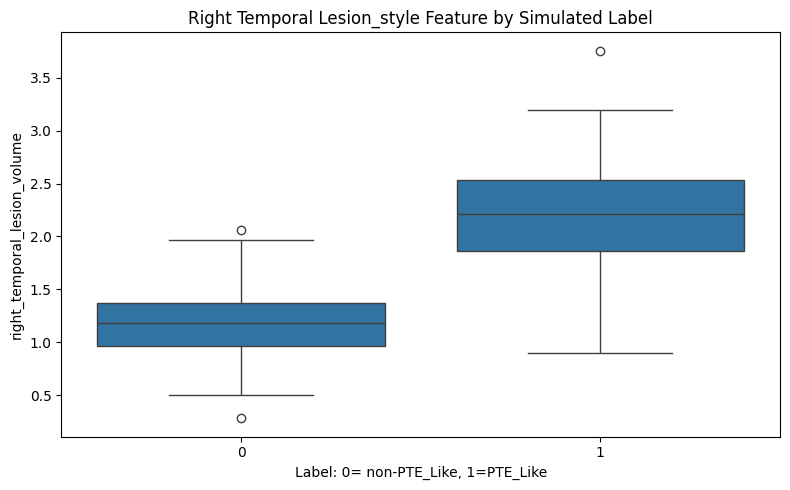

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="label", y="right_temporal_lesion_volume")
plt.title("Right Temporal Lesion_style Feature by Simulated Label")
plt.xlabel("Label: 0= non-PTE_Like, 1=PTE_Like")
plt.tight_layout()
plt.show

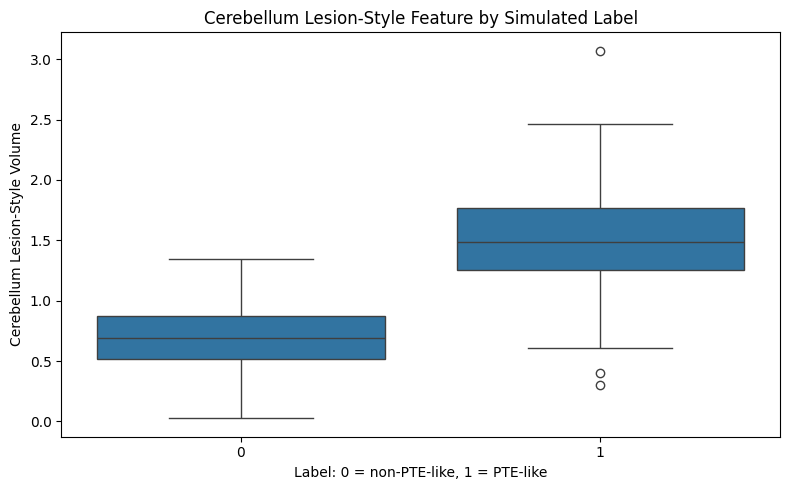

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label", y="cerebellum_lesion_volume")
plt.title("Cerebellum Lesion-Style Feature by Simulated Label")
plt.xlabel("Label: 0 = non-PTE-like, 1 = PTE-like")
plt.ylabel("Cerebellum Lesion-Style Volume")
plt.tight_layout()
plt.show()

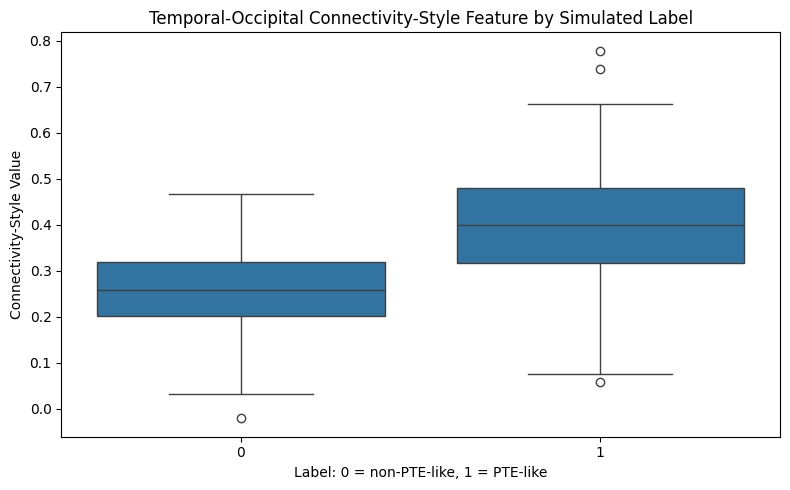

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="label", y="temporal_occipital_connectivity")
plt.title("Temporal-Occipital Connectivity-Style Feature by Simulated Label")
plt.xlabel("Label: 0 = non-PTE-like, 1 = PTE-like")
plt.ylabel("Connectivity-Style Value")
plt.tight_layout()
plt.show()

### Section 8: Save Dataset check

In [19]:
df.to_csv("data/simulated_pte_features.csv", index=False)
print("Saved simulated dataset to data/simulated_pte_features.csv")

Saved simulated dataset to data/simulated_pte_features.csv
